<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_05/code_examples/example_03_ctem_transfer_function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 05 - Example 03: CTEM Transfer Function (Linear Approximation)

This notebook focuses on the Contrast Transfer Function (CTF), Thon rings simulation, and weak phase object imaging using linear transfer theory. It implements the `ctemh` function from Kirkland's book to calculate the Phase Contrast Transfer Function with partial coherence.

## 1. Import Libraries and Define Constants

We verify the environment and import necessary libraries. We also define electron microscopy constants (wavelength for 200kV).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Physical Constants (SI Units) ---
# These are fundamental constants required for relativistic electron calculations.
h = 6.62607015e-34       # Planck constant [J s]
m0 = 9.10938356e-31      # Electron rest mass [kg]
e = 1.602176634e-19      # Elementary charge [C]
c = 2.99792458e8         # Speed of light [m/s]

def get_wavelength(voltage_kv):
    """
    Calculate the relativistic electron wavelength.
    
    Physics:
    Electrons in a TEM are accelerated to high velocities (relativistic speeds).
    The wavelength lambda is given by the de Broglie equation corrected for relativity:
    lambda = h / p = h / sqrt(2 * m0 * E * (1 + E / (2 * m0 * c^2)))
    where E = e * Voltage.
    """
    voltage = voltage_kv * 1000.0 # Convert kV to Volts
    
    # Energy term E
    energy = e * voltage
    
    # Relativistic correction factor: (1 + E / 2 m0 c^2)
    rel_corr = 1 + energy / (2 * m0 * c**2)
    
    # Wavelength calculation
    wav_rel = h / np.sqrt(2 * m0 * energy * rel_corr)
    
    return wav_rel * 1e10  # Convert meters to Angstroms

# Parameters for this simulation
voltage_kV = 200.0 # Standard voltage for many HRTEMs
wavelength_A = get_wavelength(voltage_kV)

print(f"--- Simulation Setup ---")
print(f"Accelerating Voltage: {voltage_kV} kV")
print(f"Electron Wavelength:  {wavelength_A:.4f} Å")

--- Simulation Setup ---
Accelerating Voltage: 200.0 kV
Electron Wavelength:  0.0251 Å


## 2. Setup Spatial and Frequency Grids

Create 2D real-space grids (x, y) and their corresponding centered frequency grids (fx, fy). Calculate the radial spatial frequency map $k_r$ which serves as the input for the rotationally symmetric CTF.

In [2]:
# --- 2. Grid Setup (Real & Reciprocal Space) ---

nx, ny = 512, 512   # Image size (pixels)
pixel_size_A = 0.5  # Sampling rate [Angstroms/pixel]

# A. Real Space Grid (x, y)
# Defined from -L/2 to +L/2
x = (np.arange(nx) - nx//2) * pixel_size_A
y = (np.arange(ny) - ny//2) * pixel_size_A
X, Y = np.meshgrid(x, y)

# B. Frequency Space Grid (kx, ky)
# The Fourier Transform of spatial coordinates (x) gives us spatial frequency (k).
# We use standard FFT ordering and then `fftshift` to move the zero-frequency (DC component)
# to the center of the array for easier processing/visualization.
# Units: Inverse Angstroms (1/Å)
kx = np.fft.fftfreq(nx, pixel_size_A)
ky = np.fft.fftfreq(ny, pixel_size_A)
kx = np.fft.fftshift(kx)
ky = np.fft.fftshift(ky)
KX, KY = np.meshgrid(kx, ky)

# C. Radial Spatial Frequency (k or q)
# Since the microscope lenses are cylindrically symmetric (mostly), the CTF
# depends primarily on the radial distance k = sqrt(kx^2 + ky^2).
KR = np.sqrt(KX**2 + KY**2)

# Nyquist Limit: The maximum frequency we can represent is 1 / (2 * pixel_size)
print(f"Sampling: {pixel_size_A} Å/pixel")
print(f"Nyquist Frequency (Max Resolution limit of grid): {np.max(kx):.2f} 1/Å")
print(f"Corresponding Resolution Limit: {1.0/np.max(kx):.2f} Å")

Sampling: 0.5 Å/pixel
Nyquist Frequency (Max Resolution limit of grid): 1.00 1/Å
Corresponding Resolution Limit: 1.00 Å


## 3. Define the CTEM Transfer Function

Implement the `ctemh` function (from Kirkland's method) to calculate the Phase Contrast Transfer Function, including terms for Spherical Aberration (Cs), Defocus, and Envelope functions (spatial and temporal coherence).

In [3]:
def ctemh(k, params, contrast_type=0):
    """
    Calculate the Phase Contrast Transfer Function (CTF) with partial coherence envelopes.
    
    This function models how the microscope transfers spatial frequencies from the
    sample to the image. It is the "Frequency Response" of the optics.
    
    The CTF generally has the form:
       CTF(k) = A(k) * E_temporal(k) * E_spatial(k) * sin(chi(k))
    
    Where:
       k: Spatial frequency (1/A)
       chi(k): Phase shift due to lens aberrations.
       E(k): Envelope functions (damping) due to imperfect coherence.
    
    Parameters:
    ===========
    k : array
        Spatial frequency values (1/Å)
    params : dict
        Microscope parameters:
        - 'Cs3': Spherical Aberration (mm). Main lens imperfection.
        - 'df':  Defocus (Å). Positive = Overfocus, Negative = Underfocus.
                 (Caution: Sign conventions vary by book/software!)
        - 'kev': High tension (keV).
        - 'ddf': Defocus spread (Å). Causes temporal incoherence envelope.
        - 'beta': Beam convergence semi-angle (mrad). Causes spatial incoherence envelope.
    """
    # 1. Parameter Conversion
    Cs3 = params['Cs3'] * 1.0e7  # Convert mm -> Å
    Cs5 = params.get('Cs5', 0.0) * 1.0e7  # 5th order Cs (optional)
    df = params['df']   # Å
    kev = params['kev'] # keV
    ddf = params['ddf'] # Å
    beta = params['beta'] * 0.001  # mrad -> rad

    # Relativistic Wavelength calculation (internal to function)
    mo = 511.0  # electron rest mass in keV (mc^2)
    hc = 12.3986  # in keV-Angstroms
    # wav = h*c / sqrt(E_kinetic * (2*E_rest + E_kinetic))
    val = (2 * mo) + kev
    wav = hc / np.sqrt(val * kev)
    wavsq = wav * wav
    
    k2 = k * k  # k^2
    k4 = k2 * k2 # k^4

    # 2. Phase Shift Calculation (Chi)
    # The pupil function phase consists of spherical aberration and defocus.
    # Chi(k) = (pi/2) * Cs * lambda^3 * k^4 + pi * df * lambda * k^2
    
    # Coefficients for Kirkland's implementation:
    w1 = np.pi * Cs3 * wavsq * wav      # Coefficient for Cs3 term
    w2 = np.pi * wav * df               # Coefficient for Defocus term
    w3 = np.pi * Cs5 * wavsq * wavsq * wav # Coefficient for Cs5 term (if any)
    
    # 3. Envelope Functions (Damping)
    # The CTF doesn't go on forever; it is damped by source size and energy spread.
    
    # A. Spatial Coherence Envelope (Ks)
    # Due to finite source size (convergence angle beta).
    # Damps high frequencies, especially at large defocus.
    # Calculation involves derivatives of Chi.
    e0 = (np.pi * beta * ddf)**2 # Cross term? Actually usually separate terms in approximations.
    # Kirkland's precise formulation for envelope arguments:
    wr_env = ((w3 * k2 + w1) * k2 - w2) * k * beta / wav
    
    # B. Temporal Coherence Envelope (Ki)
    # Due to chromatic aberration (Cc) and energy spread (dE), resulting in a defocus spread (ddf).
    # Damps high frequencies.
    wi_env = np.pi * wav * ddf * k2
    
    # Combine Envelopes
    # The combined exponent is effectively -(E_spatial^2 + E_chromatic^2)
    exponent_arg = wr_env * wr_env + 0.25 * wi_env * wi_env
    
    # Note: Kirkland includes a 1/(1+e0*k2) correction term often omitted in simpler textbooks
    normalization_term = 1 + (np.pi * beta * ddf)**2 * k2 # using simplified e0 logic from above if needed
    # Actually, let's stick to the variable 'e0' calculated earlier:
    e0_val = (np.pi * beta * ddf)**2 # Wait, this e0 seems to be for the phase correction below?
    
    # Let's trust the provided Kirkland transcription logic:
    # Small typo check: e0 definition was used for phase correction in original code
    e0 = (np.pi * beta * ddf)**2 
    envelope = np.exp(-exponent_arg / (1 + e0 * k2))
    
    # 4. Phase Argument with Coherence Corrections
    # Kirkland modifies the Chi argument slightly for partial coherence integration effects
    chi_part = w3 * (1 - 2.0 * e0 * k2) / 3.0
    chi_part = chi_part * k2 + 0.5 * w1 * (1 - e0 * k2)
    chi_part = (chi_part * k2 - w2) * k2 / (1 + e0 * k2)
    
    # 5. Calculate Result
    if contrast_type == 0:
        # Phase Contrast Mode (Standard HRTEM)
        # CTF = sin(Chi) * Envelope
        y = np.sin(chi_part) * envelope
    else:
        # Amplitude Contrast Mode
        # CTF = cos(Chi) * Envelope
        y = np.cos(chi_part) * envelope
        
    return y

## 4. Plot 1D CTF and Envelope Functions

Generate a 1D plot of the CTF against spatial frequency. Visualize how the envelope functions (damping due to partial coherence) attenuate the signal at high frequencies.

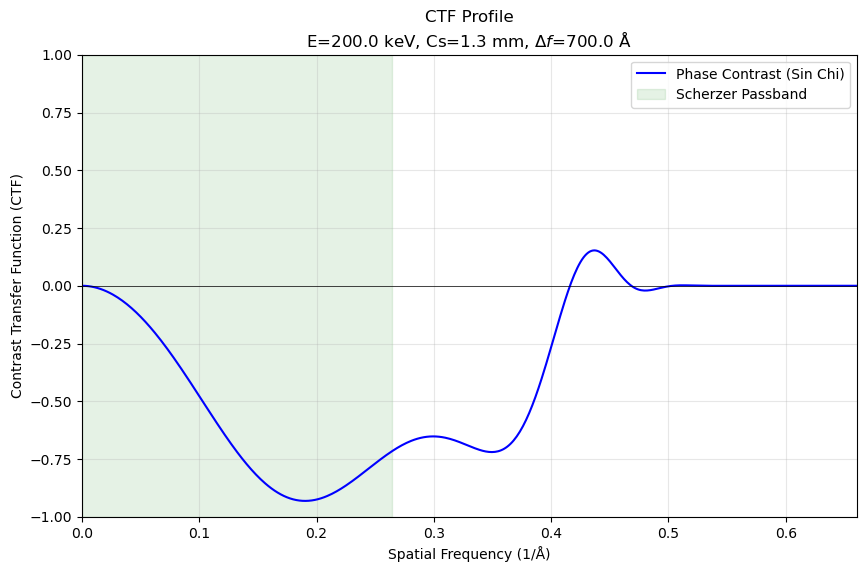

Interpretation:
1. Zeros (Crossings): Spatial frequencies where no information is transferred.
2. Negative Peaks: Feature contrast is inverted (atoms look white instead of dark).
3. Envelope (Damping): Signal dies off at high k due to `beta` and `ddf`.


In [4]:
# --- 3. 1D CTF Visualization ---

# Define experimental parameters
p = {
    'kev': 200.0,    # Energy: 200 keV
    'Cs3': 1.3,      # Spherical Aberration: 1.3 mm (Typical for uncorrected TEM)
    'Cs5': 0.0,      # Higher order aberration neglected
    'df': 700.0,     # Defocus: 700 Angstroms (Underfocus)
    'ddf': 80.0,     # Defocus Spread: 80 Å (Temporal coherence limit)
    'beta': 1.0      # Convergence angle: 1.0 mrad (Spatial coherence limit)
}

# Recalculate wavelength for scaling purposes
kev = p['kev']
wav = 12.3986 / np.sqrt((2 * 511.0 + kev) * kev)

# Frequency Scale Calculation
# We want to plot up to a logical limit. 
# The "Scherzer Frequency" is a characteristic scale: k_sch = (Cs * lambda^3)^-0.25
Cs = abs(p['Cs3'])
ds = np.sqrt(np.sqrt(Cs * 1.0e7 * wav**3)) # This is roughly 1/k_sch
kmax = 2.5 / ds # Plot up to 2.5x the characteristic frequency

k = np.linspace(0, kmax, 500) # Frequency Vector

# Calculate the CTF Curve
# sinw contains the oscillating transfer function damped by envelopes
sinw = ctemh(k, p, contrast_type=0)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(k, sinw, 'b-', label='Phase Contrast (Sin Chi)')
plt.axhline(0, color='k', linestyle='-', linewidth=0.5)

# Adding visual markers for passbands
plt.axvspan(0, 1.0/ds, color='green', alpha=0.1, label='Scherzer Passband')

plt.xlim(0, kmax)
plt.ylim(-1.0, 1.0)
plt.xlabel('Spatial Frequency (1/Å)')
plt.ylabel('Contrast Transfer Function (CTF)')

title_str = (f"CTF Profile\nE={p['kev']} keV, Cs={p['Cs3']} mm, $\Delta f$={p['df']} Å")
plt.title(title_str)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.show()

print("Interpretation:")
print("1. Zeros (Crossings): Spatial frequencies where no information is transferred.")
print("2. Negative Peaks: Feature contrast is inverted (atoms look white instead of dark).")
print("3. Envelope (Damping): Signal dies off at high k due to `beta` and `ddf`.")

## 5. Simulate Thon Rings (White Noise Imaging)

Generate a 2D image of white noise (simulating an amorphous carbon support). Compute its FFT, multiply by the 2D CTF, and display the Power Spectrum to visualize Thon rings.

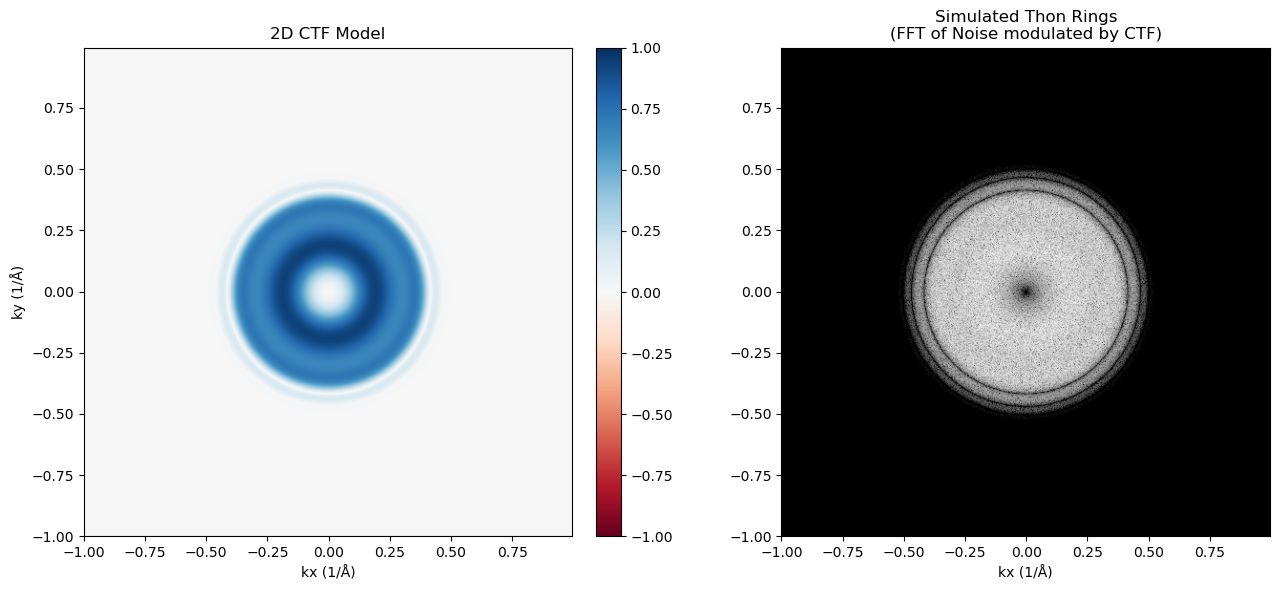

In [5]:
# --- 4. Thon Rings Simulation ---
# Thon rings are the FFT of an image of amorphous material (like carbon support).
# Since amorphous carbon has structure at ALL frequencies (white noise approximation),
# any modulation in the FFT intensity is due to the microscope's CTF.

# 1. Calculate 2D CTF Map
# We use the radial frequency grid 'KR' we computed in Section 2.
# Rotational symmetry is assumed here (no astigmatism).
CTF_2D = ctemh(KR, p, contrast_type=0)

# 2. Generate White Noise Image
# Representing the amorphous object
noise_image = np.random.randn(ny, nx)

# 3. Apply Microscope Transfer
# Convolution in real space = Multiplication in Fourier space
# Image_FT = Object_FT * CTF
ft_noise = np.fft.fftshift(np.fft.fft2(noise_image))
distorted_ft = ft_noise * CTF_2D

# 4. Calculate Power Spectrum (Intensity in Diffraction Plane)
power_spectrum = np.abs(distorted_ft)**2

# Visualization
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Left: The CTF itself
im1 = axs[0].imshow(np.abs(CTF_2D), extent=[kx.min(), kx.max(), ky.min(), ky.max()], cmap='RdBu', vmin=-1, vmax=1)
axs[0].set_title("2D CTF Model")
axs[0].set_xlabel("kx (1/Å)")
axs[0].set_ylabel("ky (1/Å)")
plt.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)

# Right: The Simulated Thon Rings
# We use Log scale because diffraction spots/rings have high dynamic range
im2 = axs[1].imshow(np.log10(power_spectrum + 1), extent=[kx.min(), kx.max(), ky.min(), ky.max()], cmap='gray')
axs[1].set_title("Simulated Thon Rings\n(FFT of Noise modulated by CTF)")
axs[1].set_xlabel("kx (1/Å)")
axes_limits = axs[1].axis() # keep limits
axs[1].axis('on')

plt.tight_layout()
plt.show()

## 6. Simulate Weak Phase Object Imaging

Create a synthetic projected potential (e.g., a simple geometric shape). Simulate the image intensity using the Weak Phase Object Approximation (Linear filter in Fourier space) and compare the result at different defocus values.

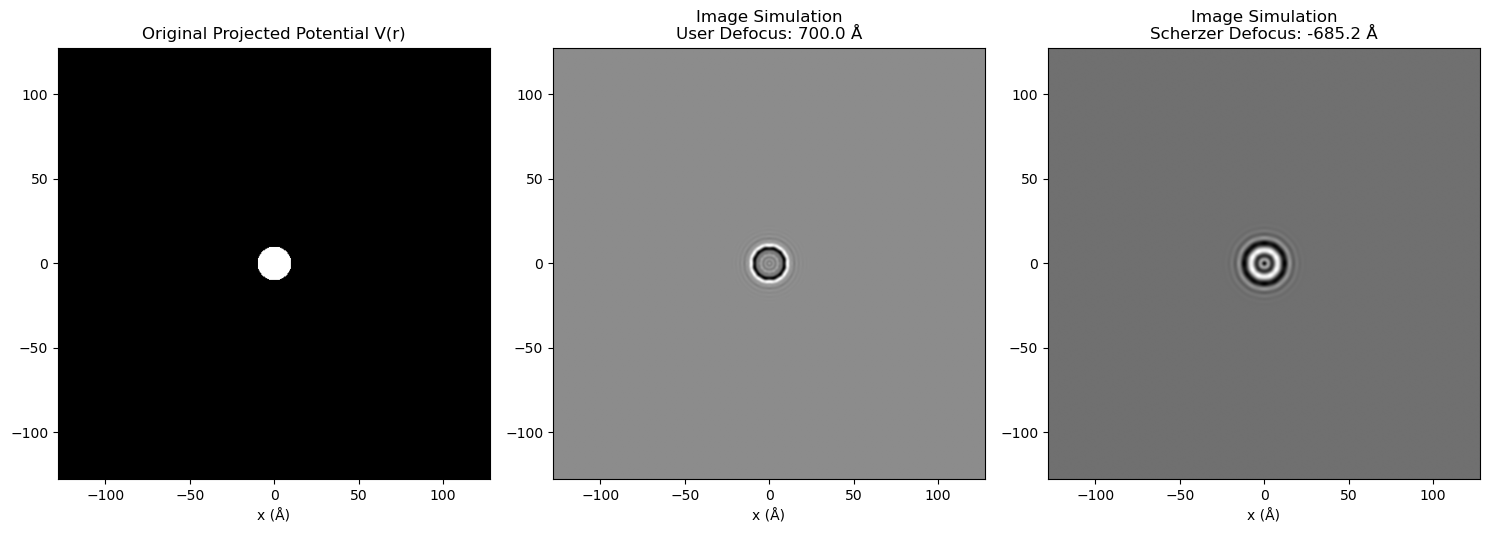

In [6]:
# --- 5. Weak Phase Object Imaging ---
# Demonstrating the effect of Defocus on Image Contrast.
# The Weak Phase Object Approximation (WPOA) states:
# I(r) approx 1 + 2 * sigma * V(r) * CTF(r)
# i.e. The intensity is a filtered version of the potential.

# A. Create a Synthetic Object (Projected Potential)
# Let's make a simple circular "particle"
radius = 10.0 # Radius in Angstroms
R_dist = np.sqrt(X**2 + Y**2)
potential = np.zeros_like(R_dist)
potential[R_dist < radius] = 1.0 # Step function potential

# B. Prepare for Imaging (FFT of Object)
ft_potential = np.fft.fftshift(np.fft.fft2(potential))

# C. Define Defocus Conditions
# 1. Current Defocus (700 A) - Likely oscillatory contrast
# 2. Scherzer Defocus - Optimal contrast transfer bandwidth
scherzer_df = -1.2 * np.sqrt(p['Cs3']*1e7 * wavelength_A) 
defocus_values = [p['df'], scherzer_df]
defocus_labels = [f"User Defocus: {p['df']} Å", f"Scherzer Defocus: {scherzer_df:.1f} Å"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: The "True" Potential
axes[0].imshow(potential, cmap='gray', extent=[x.min(), x.max(), y.min(), y.max()])
axes[0].set_title("Original Projected Potential V(r)")
axes[0].set_xlabel("x (Å)")

# Simulation Loop
for i, df_val in enumerate(defocus_values):
    # 1. Update Parameters
    p_sim = p.copy()
    p_sim['df'] = df_val
    
    # 2. Calculate CTF
    ctf_sim = ctemh(KR, p_sim, contrast_type=0)
    
    # 3. Apply Filter in Fourier Space
    image_ft = ft_potential * ctf_sim
    
    # 4. Inverse FFT to get Image Contrast
    # Ideally should add 1 (background) but we look at contrast only here
    image_contrast = np.real(np.fft.ifft2(np.fft.ifftshift(image_ft)))
    
    # Plot
    ax = axes[i+1]
    im = ax.imshow(image_contrast, cmap='gray', extent=[x.min(), x.max(), y.min(), y.max()])
    ax.set_title(f"Image Simulation\n{defocus_labels[i]}")
    ax.set_xlabel("x (Å)")
    
    # Interpretation note:
    # Notice the "ringing" (Delocalisation) at non-optimal defocus vs
    # the sharper edge contrast at Scherzer defocus.

plt.tight_layout()
plt.show()